# GB + TS nested-validation summary


In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error, r2_score

print(sys.executable)
if sys.executable != '/usr/bin/python3':
    print('WARNING: this notebook is intended to run with /usr/bin/python3.')

TASK_PATH = Path('results/nested/ferr_lig/tasks/task_001_TS_gb_inner3fold.json')

if not TASK_PATH.exists():
    raise FileNotFoundError(f'Nested-validation task not found: {TASK_PATH}')


/usr/bin/python3


## Original GB + TS Nested-LOO Result

This section uses the completed nested-screening result exactly as stored in `task_001_TS_gb.json`. Each point is one outer LOO held-out prediction.

In [2]:
with TASK_PATH.open(encoding='utf-8') as fh:
    task_payload = json.load(fh)

assert task_payload['status'] == 'ok', task_payload.get('error', 'Nested task did not finish.')
assert task_payload['task'] == {
    'task_id': 1,
    'screen': 'ferr_lig',
    'descriptor': 'TS',
    'model': 'gb',
}, task_payload['task']

folds = sorted(task_payload['folds'], key=lambda row: row['outer_fold'])
outer_folds = [row['outer_fold'] for row in folds]
assert len(folds) == 55, f'Expected 55 outer folds, found {len(folds)}.'
assert outer_folds == list(range(55)), 'Outer-fold indices are incomplete or duplicated.'

va_Y = np.asarray([row['prediction']['y_true'] for row in folds], dtype=float)
va_P = np.asarray([row['prediction']['y_pred'] for row in folds], dtype=float)

original_metrics = {
    'n_folds': len(folds),
    'r2': r2_score(va_Y, va_P),
    'pearson_r': pearsonr(va_Y, va_P)[0],
    'mae_kcal_mol': mean_absolute_error(va_Y, va_P),
}
original_metrics


{'n_folds': 55,
 'r2': 0.196472355058809,
 'pearson_r': 0.5798721799359314,
 'mae_kcal_mol': 0.2812074536501081}

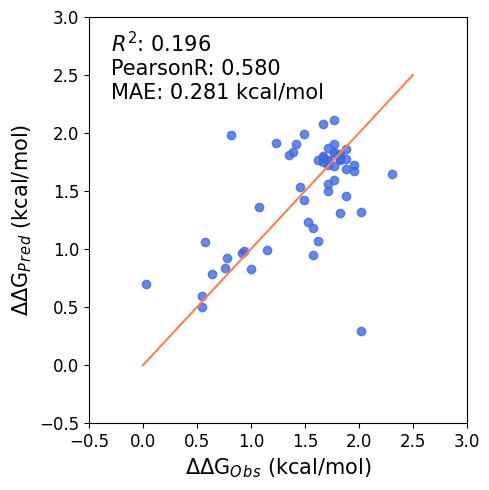

In [3]:
label_fontsize = 15
tick_fontsize = 12
plt.figure(figsize=(5,5))
plt.scatter(va_Y,va_P,color='royalblue',alpha=0.8)
plt.plot([0,2.5],[0,2.5],color='coral')
plt.xlabel('ΔΔG$_O$$_b$$_s$ (kcal/mol)',fontsize=label_fontsize)
plt.ylabel('ΔΔG$_P$$_r$$_e$$_d$ (kcal/mol)',fontsize=label_fontsize)
plt.xlim([-0.5,3])
plt.ylim([-0.5,3])
plt.xticks(fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)
plt.text(-0.3,2.3,f'$R^2$: {r2_score(va_Y,va_P):.3f}\nPearsonR: {pearsonr(va_Y,va_P)[0]:.3f}\nMAE: {mean_absolute_error(va_Y,va_P):.3f} kcal/mol',fontsize=15)
plt.tight_layout()
plt.show()


In [4]:
original_fold_table = pd.DataFrame(
    {
        'outer_fold': [row['outer_fold'] for row in folds],
        'y_observed': va_Y,
        'y_predicted': va_P,
        'absolute_error': [row['prediction']['absolute_error'] for row in folds],
        'topk': [row['best']['topk'] for row in folds],
        'objective_value': [row['best']['objective_value'] for row in folds],
        'n_estimators': [row['best']['model_params']['n_estimators'] for row in folds],
        'min_samples_split': [row['best']['model_params']['min_samples_split'] for row in folds],
        'max_depth': [row['best']['model_params']['max_depth'] for row in folds],
    }
)
original_fold_table


,outer_fold,y_observed,y_predicted,absolute_error,topk,objective_value,n_estimators,min_samples_split,max_depth
0,0,1.714028,1.767231,0.053203,300,0.198046,198,6,30
1,1,1.766687,1.835754,0.069067,300,0.220259,187,6,25
2,2,1.455955,1.532658,0.076703,300,0.160242,122,6,10
3,3,1.823260,1.815639,0.007621,300,0.159736,105,6,10
4,4,1.884432,1.780127,0.104306,300,0.354623,112,6,3
5,5,1.352207,1.814670,0.462463,300,0.089609,105,6,10
6,6,1.823260,1.311444,0.511816,446,0.421735,51,4,3
7,7,1.766687,2.115338,0.348651,300,-0.017727,212,6,33
8,8,2.303380,1.650651,0.652730,300,0.204056,105,6,10
9,9,1.493615,1.423685,0.069930,300,0.086108,158,6,21
